# Поширотный анализ стационарности временных ходов foF2

Ноутбук для 4-й статьи. Анализ стационарности выполняется по тем же feature-файлам станций, которые использовались для задачи 24-часового прогноза foF2.

Логика расчета:

1. Читаются файлы `features_2024_2025_exploration_v0_1_15min/stations/*_features.csv`.
2. Оставляются строки, где одновременно заполнены `foF2` и `foF2_target_24h`.
3. Значения foF2 с шагом 15 минут агрегируются до дневных средних временных ходов.
4. Добавляются широта станции и широтная зона.
5. Для каждой станции рассчитываются ADF- и KPSS-критерии стационарности.
6. Результаты обобщаются по широтным зонам и сохраняются графики для статьи.

Модели машинного обучения в этом ноутбуке не обучаются.

In [1]:
# Подготовка библиотек, путей к данным и общих настроек ноутбука.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
if not (ROOT / 'features_2024_2025_exploration_v0_1_15min').exists():
    ROOT = ROOT.parent
FEATURE_DIR = ROOT / 'features_2024_2025_exploration_v0_1_15min' / 'stations'
META_PATH = ROOT / 'reports' / 'fof2_fast_ml_24h_station_metadata.csv'
OUT_DIR = ROOT / 'reports' / 'stationarity_latitude_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'foF2'
TARGET_HORIZON = 'foF2_target_24h'
ALPHA = 0.05
ZONE_ORDER = ['Low', 'S_mid', 'N_mid', 'N_high']
ZONE_LABELS = {
    'Low': 'Низкие широты',
    'S_mid': 'Южные средние широты',
    'N_mid': 'Северные средние широты',
    'N_high': 'Северные высокие широты',
}

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 220
print('Корень проекта:', ROOT)
print('Папка feature-файлов:', FEATURE_DIR)
print('Папка результатов:', OUT_DIR)

Корень проекта: D:\Проекты\IonoAutoML
Папка feature-файлов: D:\Проекты\IonoAutoML\features_2024_2025_exploration_v0_1_15min\stations
Папка результатов: D:\Проекты\IonoAutoML\reports\stationarity_latitude_analysis


## 1. Загрузка временных ходов, использованных при обучении

Для анализа используются значения `foF2` из feature-файлов. Оставляются только те моменты времени, для которых существует целевое значение `foF2_target_24h`. Это позволяет проверять стационарность именно на той части временных ходов, которая соответствует постановке 24-часового прогноза.

In [2]:
# Загрузка метаданных станций: широта и широтная зона.
meta = pd.read_csv(META_PATH)
meta['latitude_zone'] = pd.Categorical(meta['latitude_zone'], categories=ZONE_ORDER, ordered=True)
meta.head()

,station,latitude,latitude_zone
0,AL945,45.07,N_mid
1,AS00Q,-8.00,Low
2,AT138,38.00,N_mid
3,AU930,30.40,N_mid
4,BR52P,-27.53,Low


In [3]:
# Поиск feature-файлов станций, которые использовались для обучения моделей.
feature_files = sorted(FEATURE_DIR.glob('*_features.csv'))
print('Feature-файлов станций:', len(feature_files))

Feature-файлов станций: 41


In [4]:
# Загрузка обучающих временных ходов foF2 и формирование дневных средних значений.
usecols = ['time_utc', 'station', TARGET, TARGET_HORIZON]
parts = []
skipped = []

for path in feature_files:
    station_from_name = path.name.replace('_features.csv', '')
    try:
        df = pd.read_csv(path, usecols=usecols)
    except ValueError as exc:
        skipped.append((station_from_name, str(exc)))
        continue
    # Оставляем только строки, которые реально могли участвовать в задаче 24-часового прогноза.
    df = df.dropna(subset=[TARGET, TARGET_HORIZON]).copy()
    df['time_utc'] = pd.to_datetime(df['time_utc'], utc=True, errors='coerce')
    df = df.dropna(subset=['time_utc'])
    if df.empty:
        skipped.append((station_from_name, 'no valid foF2/target rows'))
        continue
    df['date'] = df['time_utc'].dt.floor('D')
    daily_station = df.groupby(['station', 'date'], as_index=False)[TARGET].mean()
    parts.append(daily_station)

if not parts:
    raise RuntimeError('No station time series were loaded.')

daily = pd.concat(parts, ignore_index=True)
daily = daily.groupby(['station', 'date'], as_index=False)[TARGET].mean()
daily = daily.merge(meta, on='station', how='left')
daily = daily.dropna(subset=['latitude', 'latitude_zone'])
daily['latitude_zone'] = pd.Categorical(daily['latitude_zone'], categories=ZONE_ORDER, ordered=True)

daily.to_csv(OUT_DIR / 'fof2_daily_training_series_by_station.csv', index=False, encoding='utf-8-sig')
print('Дневных строк:', daily.shape[0])
print('Станций:', daily['station'].nunique())
print('Пропущено:', skipped)
daily.head()

Дневных строк: 21611
Станций: 35
Пропущено: []


,station,date,foF2,latitude,latitude_zone
0,AL945,2024-01-16 00:00:00+00:00,10.281781,45.07,N_mid
1,AL945,2024-01-17 00:00:00+00:00,7.500812,45.07,N_mid
2,AL945,2024-01-18 00:00:00+00:00,7.060360,45.07,N_mid
3,AL945,2024-01-19 00:00:00+00:00,7.130435,45.07,N_mid
4,AL945,2024-01-20 00:00:00+00:00,7.161333,45.07,N_mid


## 2. Описательная статистика временных ходов

In [5]:
# Расчет описательной статистики foF2 по каждой станции.
station_stats = (
    daily.groupby(['station', 'latitude', 'latitude_zone'], observed=True)[TARGET]
    .agg(n_days='count', mean='mean', median='median', std='std', min='min', max='max')
    .reset_index()
)
station_stats['cv'] = station_stats['std'] / station_stats['mean']
station_stats.to_csv(OUT_DIR / 'station_fof2_training_descriptive_stats.csv', index=False, encoding='utf-8-sig')
station_stats.head()

,station,latitude,latitude_zone,n_days,mean,median,std,min,max,cv
0,AL945,45.07,N_mid,650,6.897477,6.903640,1.148078,3.085056,12.036367,0.166449
1,AS00Q,-8.00,Low,685,10.237822,10.412615,1.324213,5.460227,13.708696,0.129345
2,AT138,38.00,N_mid,662,7.299593,7.270399,1.008583,4.274015,9.682862,0.138170
3,AU930,30.40,N_mid,129,7.525128,7.492264,0.926292,5.818986,10.896384,0.123093
4,BR52P,-27.53,Low,718,8.382574,8.606527,1.130157,5.467927,11.963529,0.134822


In [6]:
# Обобщение описательной статистики по широтным зонам.
zone_stats = (
    station_stats.groupby('latitude_zone', observed=True)
    .agg(
        stations=('station', 'nunique'),
        days_mean=('n_days', 'mean'),
        fof2_mean=('mean', 'mean'),
        fof2_std_mean=('std', 'mean'),
        cv_mean=('cv', 'mean'),
    )
    .reindex(ZONE_ORDER)
    .reset_index()
)
zone_stats['latitude_zone_label'] = zone_stats['latitude_zone'].map(ZONE_LABELS)
zone_stats.to_csv(OUT_DIR / 'zone_fof2_training_descriptive_stats.csv', index=False, encoding='utf-8-sig')
zone_stats

,latitude_zone,stations,days_mean,fof2_mean,fof2_std_mean,cv_mean,latitude_zone_label
0,Low,11,581.181818,9.625322,1.384147,0.145339,Низкие широты
1,S_mid,4,712.750000,7.129246,1.047293,0.146761,Южные средние широты
2,N_mid,18,607.888889,7.263099,1.028223,0.142114,Северные средние широты
3,N_high,2,712.500000,5.699058,0.868094,0.152088,Северные высокие широты


## 3. Проверка стационарности по ADF и KPSS

Используются два статистических критерия:

- **ADF**: нулевая гипотеза — ряд нестационарен. Если `p-value < 0.05`, есть основание считать ряд стационарным.
- **KPSS**: нулевая гипотеза — ряд стационарен. Если `p-value > 0.05`, нет основания отвергать стационарность.

Ряд относится к стационарным, если ADF отвергает нестационарность, а KPSS не отвергает стационарность. Отдельно выделяется вариант стационарности относительно тренда.

In [7]:
# Функция выполняет ADF- и KPSS-проверку стационарности для одного временного ряда.
def run_stationarity_tests(values):
    x = pd.Series(values).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    result = {
        'n_obs': int(x.size),
        'adf_c_stat': np.nan, 'adf_c_pvalue': np.nan,
        'adf_ct_stat': np.nan, 'adf_ct_pvalue': np.nan,
        'kpss_c_stat': np.nan, 'kpss_c_pvalue': np.nan,
        'kpss_ct_stat': np.nan, 'kpss_ct_pvalue': np.nan,
    }
    if x.size < 30 or x.nunique() < 3:
        result['stationarity_class'] = 'insufficient_data'
        return result
    try:
        adf_c = adfuller(x, regression='c', autolag='AIC')
        result['adf_c_stat'], result['adf_c_pvalue'] = adf_c[0], adf_c[1]
    except Exception:
        pass
    try:
        adf_ct = adfuller(x, regression='ct', autolag='AIC')
        result['adf_ct_stat'], result['adf_ct_pvalue'] = adf_ct[0], adf_ct[1]
    except Exception:
        pass
    try:
        kpss_c = kpss(x, regression='c', nlags='auto')
        result['kpss_c_stat'], result['kpss_c_pvalue'] = kpss_c[0], kpss_c[1]
    except Exception:
        pass
    try:
        kpss_ct = kpss(x, regression='ct', nlags='auto')
        result['kpss_ct_stat'], result['kpss_ct_pvalue'] = kpss_ct[0], kpss_ct[1]
    except Exception:
        pass
    # Строгий вывод требует согласия двух тестов: ADF за стационарность, KPSS не против нее.
    strict = (result['adf_c_pvalue'] < ALPHA) and (result['kpss_c_pvalue'] > ALPHA)
    # Если обычная стационарность не подтверждена, отдельно проверяется стационарность относительно тренда.
    trend = (result['adf_ct_pvalue'] < ALPHA) and (result['kpss_ct_pvalue'] > ALPHA)
    if strict:
        result['stationarity_class'] = 'stationary'
    elif trend:
        result['stationarity_class'] = 'trend_stationary'
    else:
        result['stationarity_class'] = 'nonstationary'
    return result

rows = []
for station, g in daily.sort_values('date').groupby('station'):
    tests = run_stationarity_tests(g[TARGET])
    info = g[['station', 'latitude', 'latitude_zone']].iloc[0].to_dict()
    rows.append({**info, **tests})

stationarity = pd.DataFrame(rows)
stationarity['latitude_zone'] = pd.Categorical(stationarity['latitude_zone'], categories=ZONE_ORDER, ordered=True)
stationarity['latitude_zone_label'] = stationarity['latitude_zone'].map(ZONE_LABELS)
stationarity = stationarity.sort_values(['latitude_zone', 'latitude', 'station'])
stationarity.to_csv(OUT_DIR / 'stationarity_tests_by_station_training_rows.csv', index=False, encoding='utf-8-sig')
stationarity.head(10)

,station,latitude,latitude_zone,n_obs,adf_c_stat,adf_c_pvalue,adf_ct_stat,adf_ct_pvalue,kpss_c_stat,kpss_c_pvalue,kpss_ct_stat,kpss_ct_pvalue,stationarity_class,latitude_zone_label
26,NI63,-29.03,Low,721,-2.002882,0.285311,-1.882676,0.663598,0.690827,0.014379,0.256194,0.010000,nonstationary,Низкие широты
4,BR52P,-27.53,Low,718,-2.299698,0.172065,-2.297062,0.435576,0.751179,0.010000,0.226147,0.010000,nonstationary,Низкие широты
5,CAJ2M,-22.70,Low,676,-1.592550,0.487335,-1.566886,0.805131,0.322403,0.100000,0.224538,0.010000,nonstationary,Низкие широты
22,LM42B,-21.80,Low,414,-1.768219,0.396350,-1.451284,0.845224,1.115630,0.010000,0.522981,0.010000,nonstationary,Низкие широты
7,CGK21,-20.50,Low,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_data,Низкие широты
24,ND61R,-19.07,Low,707,-2.043726,0.267736,-2.104989,0.543302,0.473668,0.047597,0.222949,0.010000,nonstationary,Низкие широты
10,DW41K,-12.45,Low,706,-2.166029,0.218805,-2.207934,0.485386,0.544107,0.031733,0.190847,0.019432,nonstationary,Низкие широты
8,CS31K,-12.18,Low,669,-2.776027,0.061781,-3.021440,0.126185,0.601598,0.022491,0.192693,0.018740,nonstationary,Низкие широты
1,AS00Q,-8.00,Low,685,-2.372046,0.149782,-2.535875,0.310264,0.602807,0.022381,0.213382,0.010982,nonstationary,Низкие широты
34,WA619,19.29,Low,362,-2.046195,0.266693,-2.011695,0.595049,0.488669,0.044219,0.451612,0.010000,nonstationary,Низкие широты


In [8]:
# Формирование сводной таблицы стационарности по широтным зонам.
zone_stationarity_summary = (
    stationarity.groupby('latitude_zone', observed=True)
    .agg(
        stations=('station', 'nunique'),
        stationary=('stationarity_class', lambda s: (s == 'stationary').sum()),
        trend_stationary=('stationarity_class', lambda s: (s == 'trend_stationary').sum()),
        nonstationary=('stationarity_class', lambda s: (s == 'nonstationary').sum()),
        insufficient_data=('stationarity_class', lambda s: (s == 'insufficient_data').sum()),
        adf_c_pvalue_median=('adf_c_pvalue', 'median'),
        kpss_c_pvalue_median=('kpss_c_pvalue', 'median'),
    )
    .reindex(ZONE_ORDER)
    .reset_index()
)
zone_stationarity_summary['stationary_share'] = zone_stationarity_summary['stationary'] / zone_stationarity_summary['stations']
zone_stationarity_summary['stationary_or_trend_share'] = (zone_stationarity_summary['stationary'] + zone_stationarity_summary['trend_stationary']) / zone_stationarity_summary['stations']
zone_stationarity_summary['latitude_zone_label'] = zone_stationarity_summary['latitude_zone'].map(ZONE_LABELS)
zone_stationarity_summary.to_csv(OUT_DIR / 'zone_stationarity_summary_training_rows.csv', index=False, encoding='utf-8-sig')
zone_stationarity_summary

,latitude_zone,stations,stationary,trend_stationary,nonstationary,insufficient_data,adf_c_pvalue_median,kpss_c_pvalue_median,stationary_share,stationary_or_trend_share,latitude_zone_label
0,Low,11,1,0,9,1,0.242749,0.027112,0.090909,0.090909,Низкие широты
1,S_mid,4,0,1,3,0,0.073512,0.010000,0.000000,0.250000,Южные средние широты
2,N_mid,18,1,3,14,0,0.016300,0.010000,0.055556,0.222222,Северные средние широты
3,N_high,2,0,1,1,0,0.137705,0.010000,0.000000,0.500000,Северные высокие широты


## 4. Графики для статьи

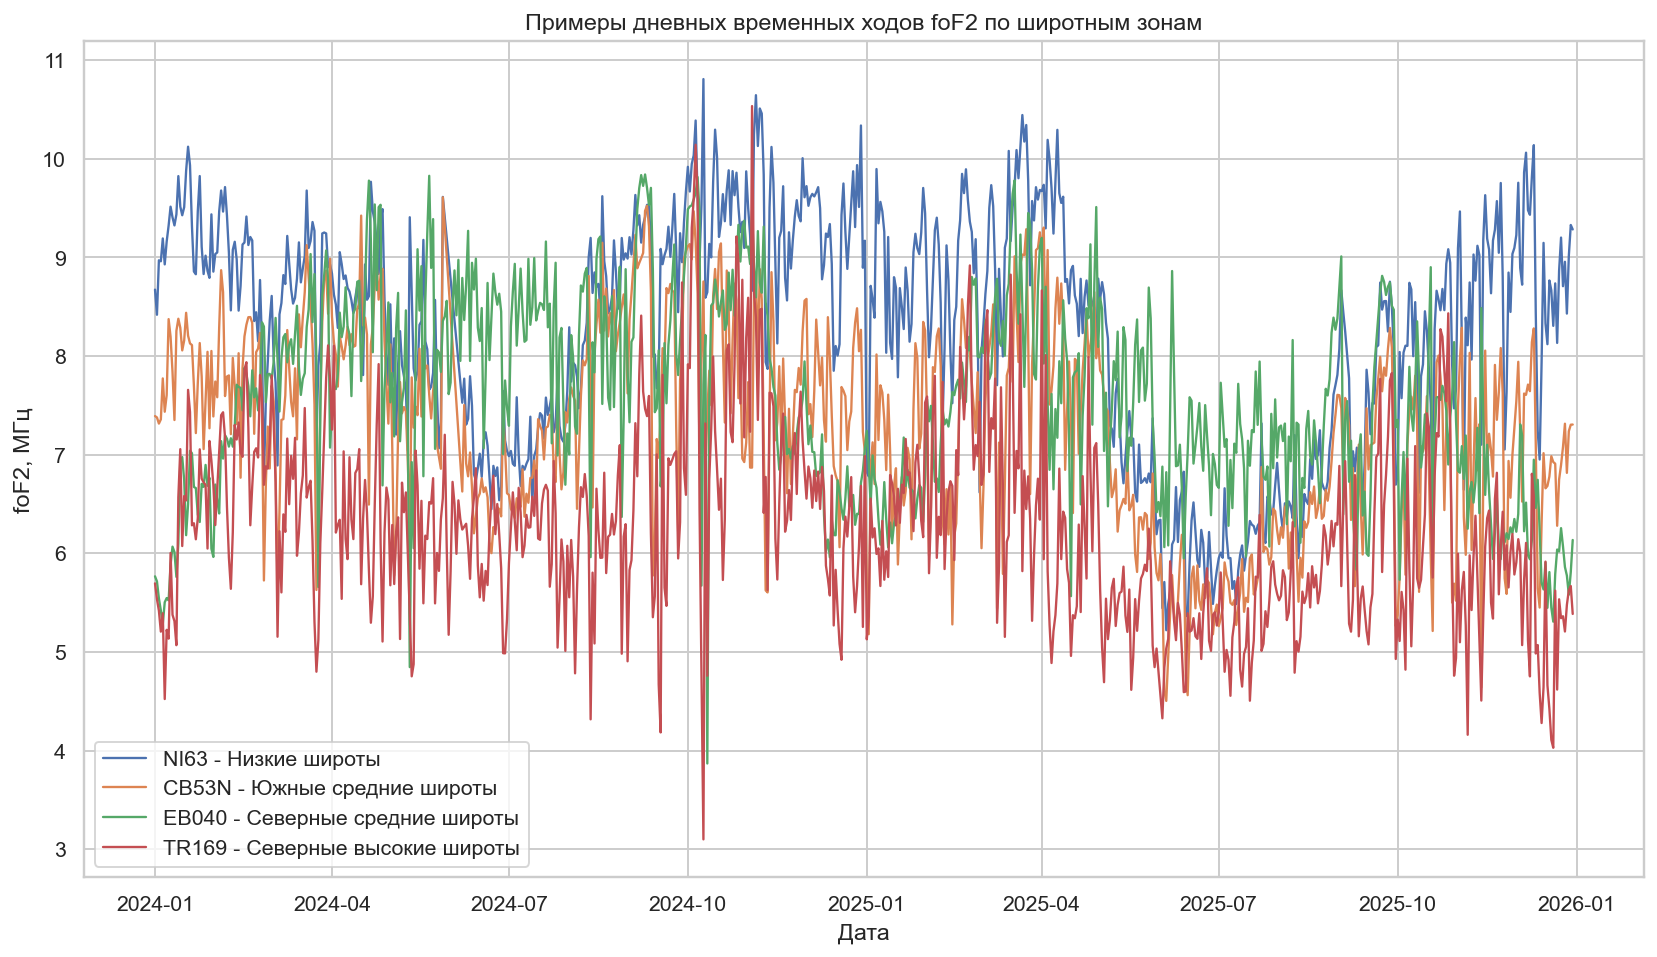

WindowsPath('D:/Проекты/IonoAutoML/reports/stationarity_latitude_analysis/training_daily_fof2_examples_by_latitude_zone.png')

In [9]:
# Функция сохраняет график в папку результатов.
def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    return path

example_stations = (
    station_stats.sort_values(['latitude_zone', 'n_days'], ascending=[True, False])
    .groupby('latitude_zone', observed=True)
    .head(1)['station']
    .tolist()
)

plt.figure(figsize=(12, 7))
for station in example_stations:
    g = daily[daily['station'] == station].sort_values('date')
    zone = g['latitude_zone'].iloc[0]
    plt.plot(g['date'], g[TARGET], linewidth=1.2, label=f"{station} - {ZONE_LABELS[zone]}")
plt.title('Примеры дневных временных ходов foF2 по широтным зонам')
plt.xlabel('Дата')
plt.ylabel('foF2, МГц')
plt.legend()
savefig('training_daily_fof2_examples_by_latitude_zone.png')

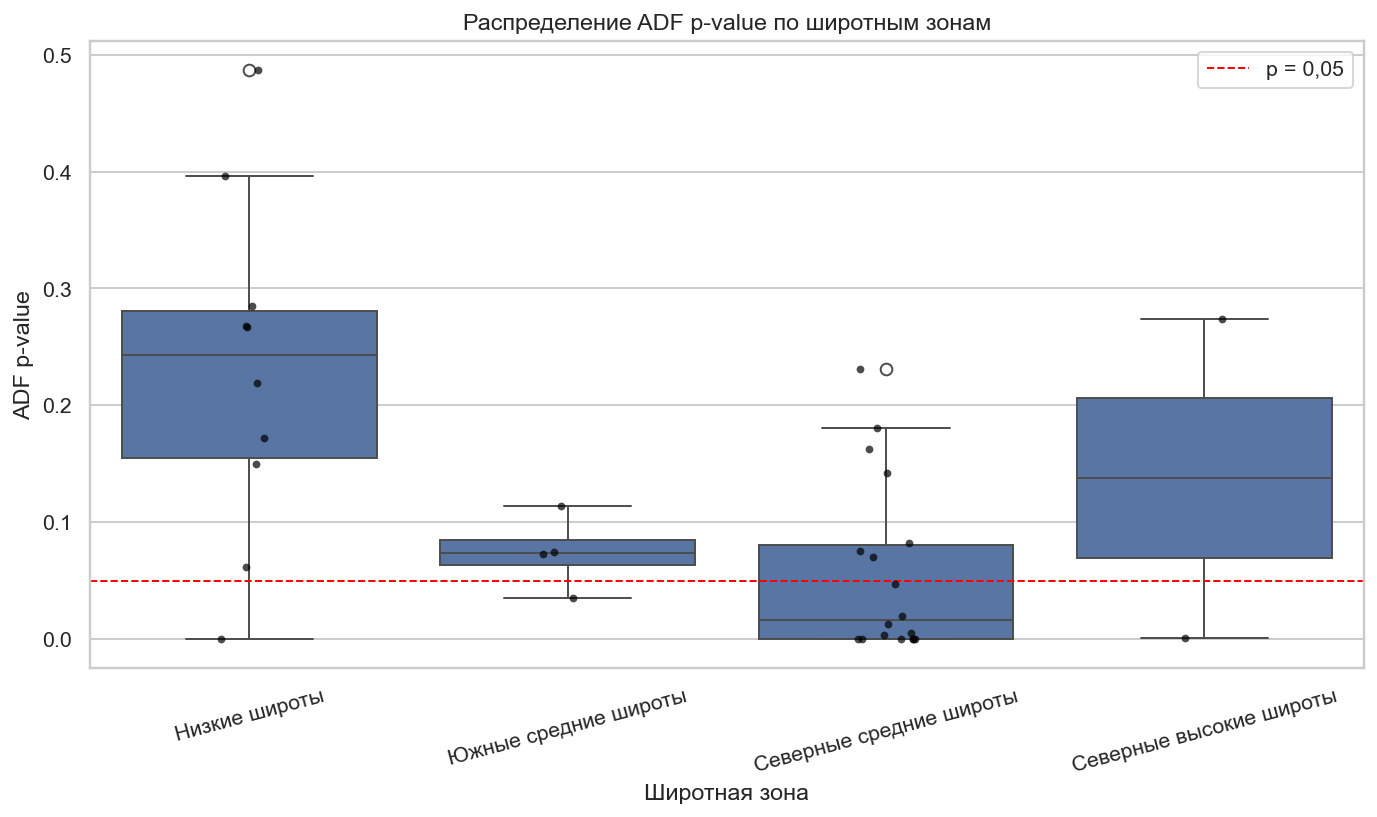

WindowsPath('D:/Проекты/IonoAutoML/reports/stationarity_latitude_analysis/training_adf_pvalue_distribution_by_latitude_zone.png')

In [10]:
# Построение графика для статьи.
plt.figure(figsize=(10, 6))
plot_df = stationarity.dropna(subset=['adf_c_pvalue']).copy()
plot_df['latitude_zone_label'] = plot_df['latitude_zone'].map(ZONE_LABELS)
sns.boxplot(data=plot_df, x='latitude_zone_label', y='adf_c_pvalue', order=[ZONE_LABELS[z] for z in ZONE_ORDER])
sns.stripplot(data=plot_df, x='latitude_zone_label', y='adf_c_pvalue', order=[ZONE_LABELS[z] for z in ZONE_ORDER], color='black', size=4, alpha=0.7)
plt.axhline(ALPHA, color='red', linestyle='--', linewidth=1, label='p = 0,05')
plt.title('Распределение ADF p-value по широтным зонам')
plt.xlabel('Широтная зона')
plt.ylabel('ADF p-value')
plt.xticks(rotation=15)
plt.legend()
savefig('training_adf_pvalue_distribution_by_latitude_zone.png')

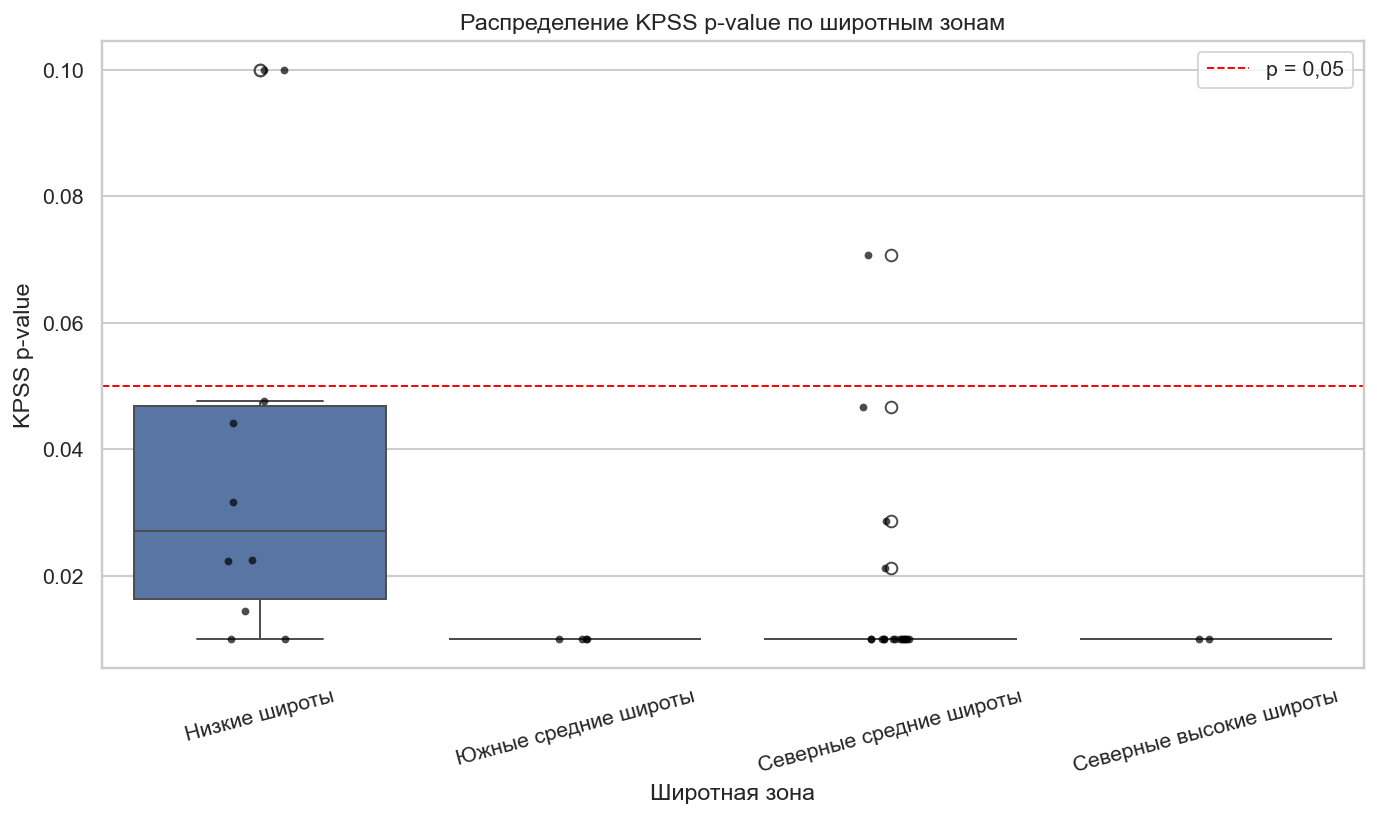

WindowsPath('D:/Проекты/IonoAutoML/reports/stationarity_latitude_analysis/training_kpss_pvalue_distribution_by_latitude_zone.png')

In [11]:
# Построение графика для статьи.
plt.figure(figsize=(10, 6))
plot_df = stationarity.dropna(subset=['kpss_c_pvalue']).copy()
plot_df['latitude_zone_label'] = plot_df['latitude_zone'].map(ZONE_LABELS)
sns.boxplot(data=plot_df, x='latitude_zone_label', y='kpss_c_pvalue', order=[ZONE_LABELS[z] for z in ZONE_ORDER])
sns.stripplot(data=plot_df, x='latitude_zone_label', y='kpss_c_pvalue', order=[ZONE_LABELS[z] for z in ZONE_ORDER], color='black', size=4, alpha=0.7)
plt.axhline(ALPHA, color='red', linestyle='--', linewidth=1, label='p = 0,05')
plt.title('Распределение KPSS p-value по широтным зонам')
plt.xlabel('Широтная зона')
plt.ylabel('KPSS p-value')
plt.xticks(rotation=15)
plt.legend()
savefig('training_kpss_pvalue_distribution_by_latitude_zone.png')

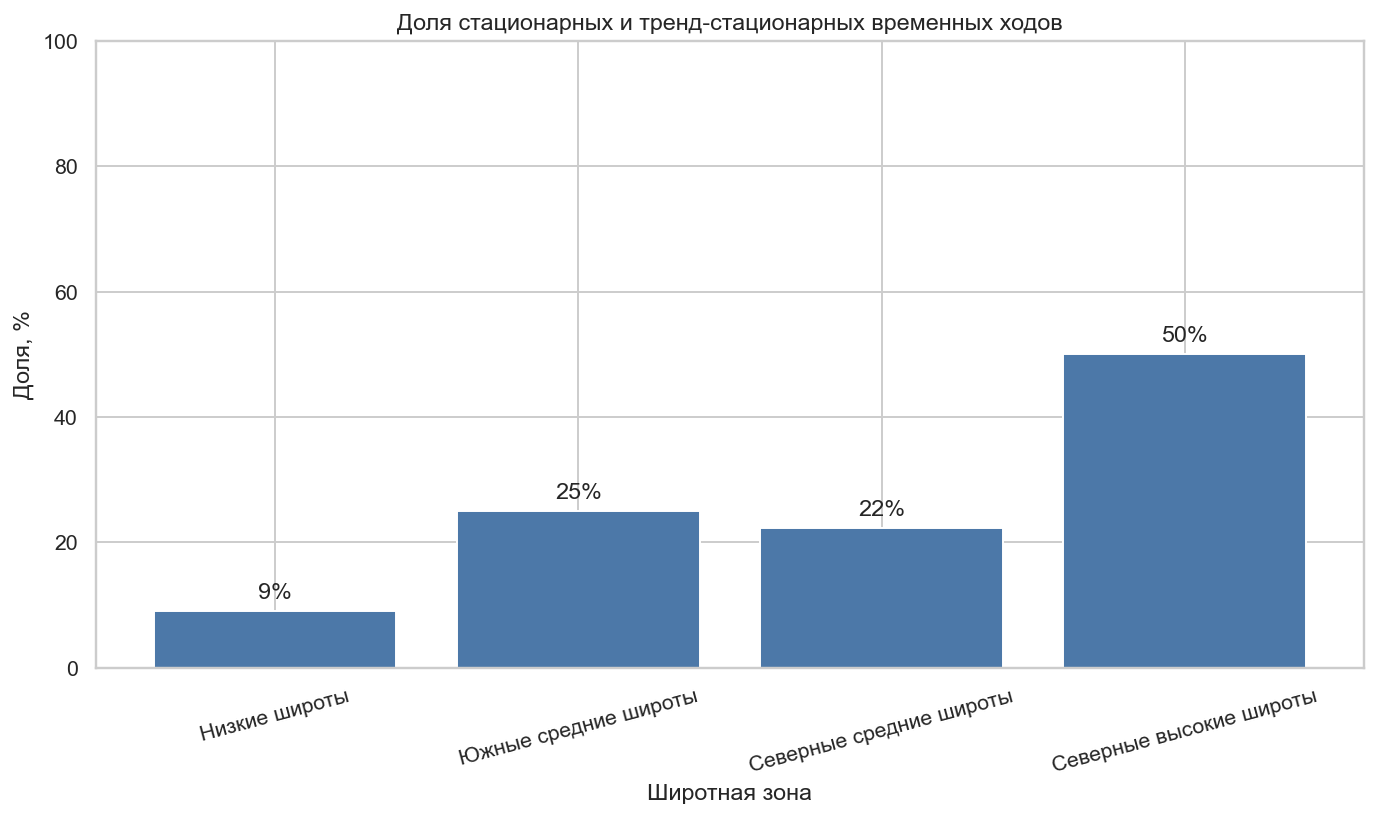

WindowsPath('D:/Проекты/IonoAutoML/reports/stationarity_latitude_analysis/training_stationary_share_by_latitude_zone.png')

In [12]:
# Выполнение расчетного шага и вывод промежуточного результата.
plot_df = zone_stationarity_summary.copy()
plot_df['latitude_zone_label'] = plot_df['latitude_zone'].map(ZONE_LABELS)
plt.figure(figsize=(10, 6))
plt.bar(plot_df['latitude_zone_label'], plot_df['stationary_or_trend_share'] * 100, color='#4C78A8')
plt.ylim(0, 100)
plt.title('Доля стационарных и тренд-стационарных временных ходов')
plt.xlabel('Широтная зона')
plt.ylabel('Доля, %')
plt.xticks(rotation=15)
for i, v in enumerate(plot_df['stationary_or_trend_share'] * 100):
    if pd.notna(v):
        plt.text(i, v + 2, f'{v:.0f}%', ha='center')
savefig('training_stationary_share_by_latitude_zone.png')

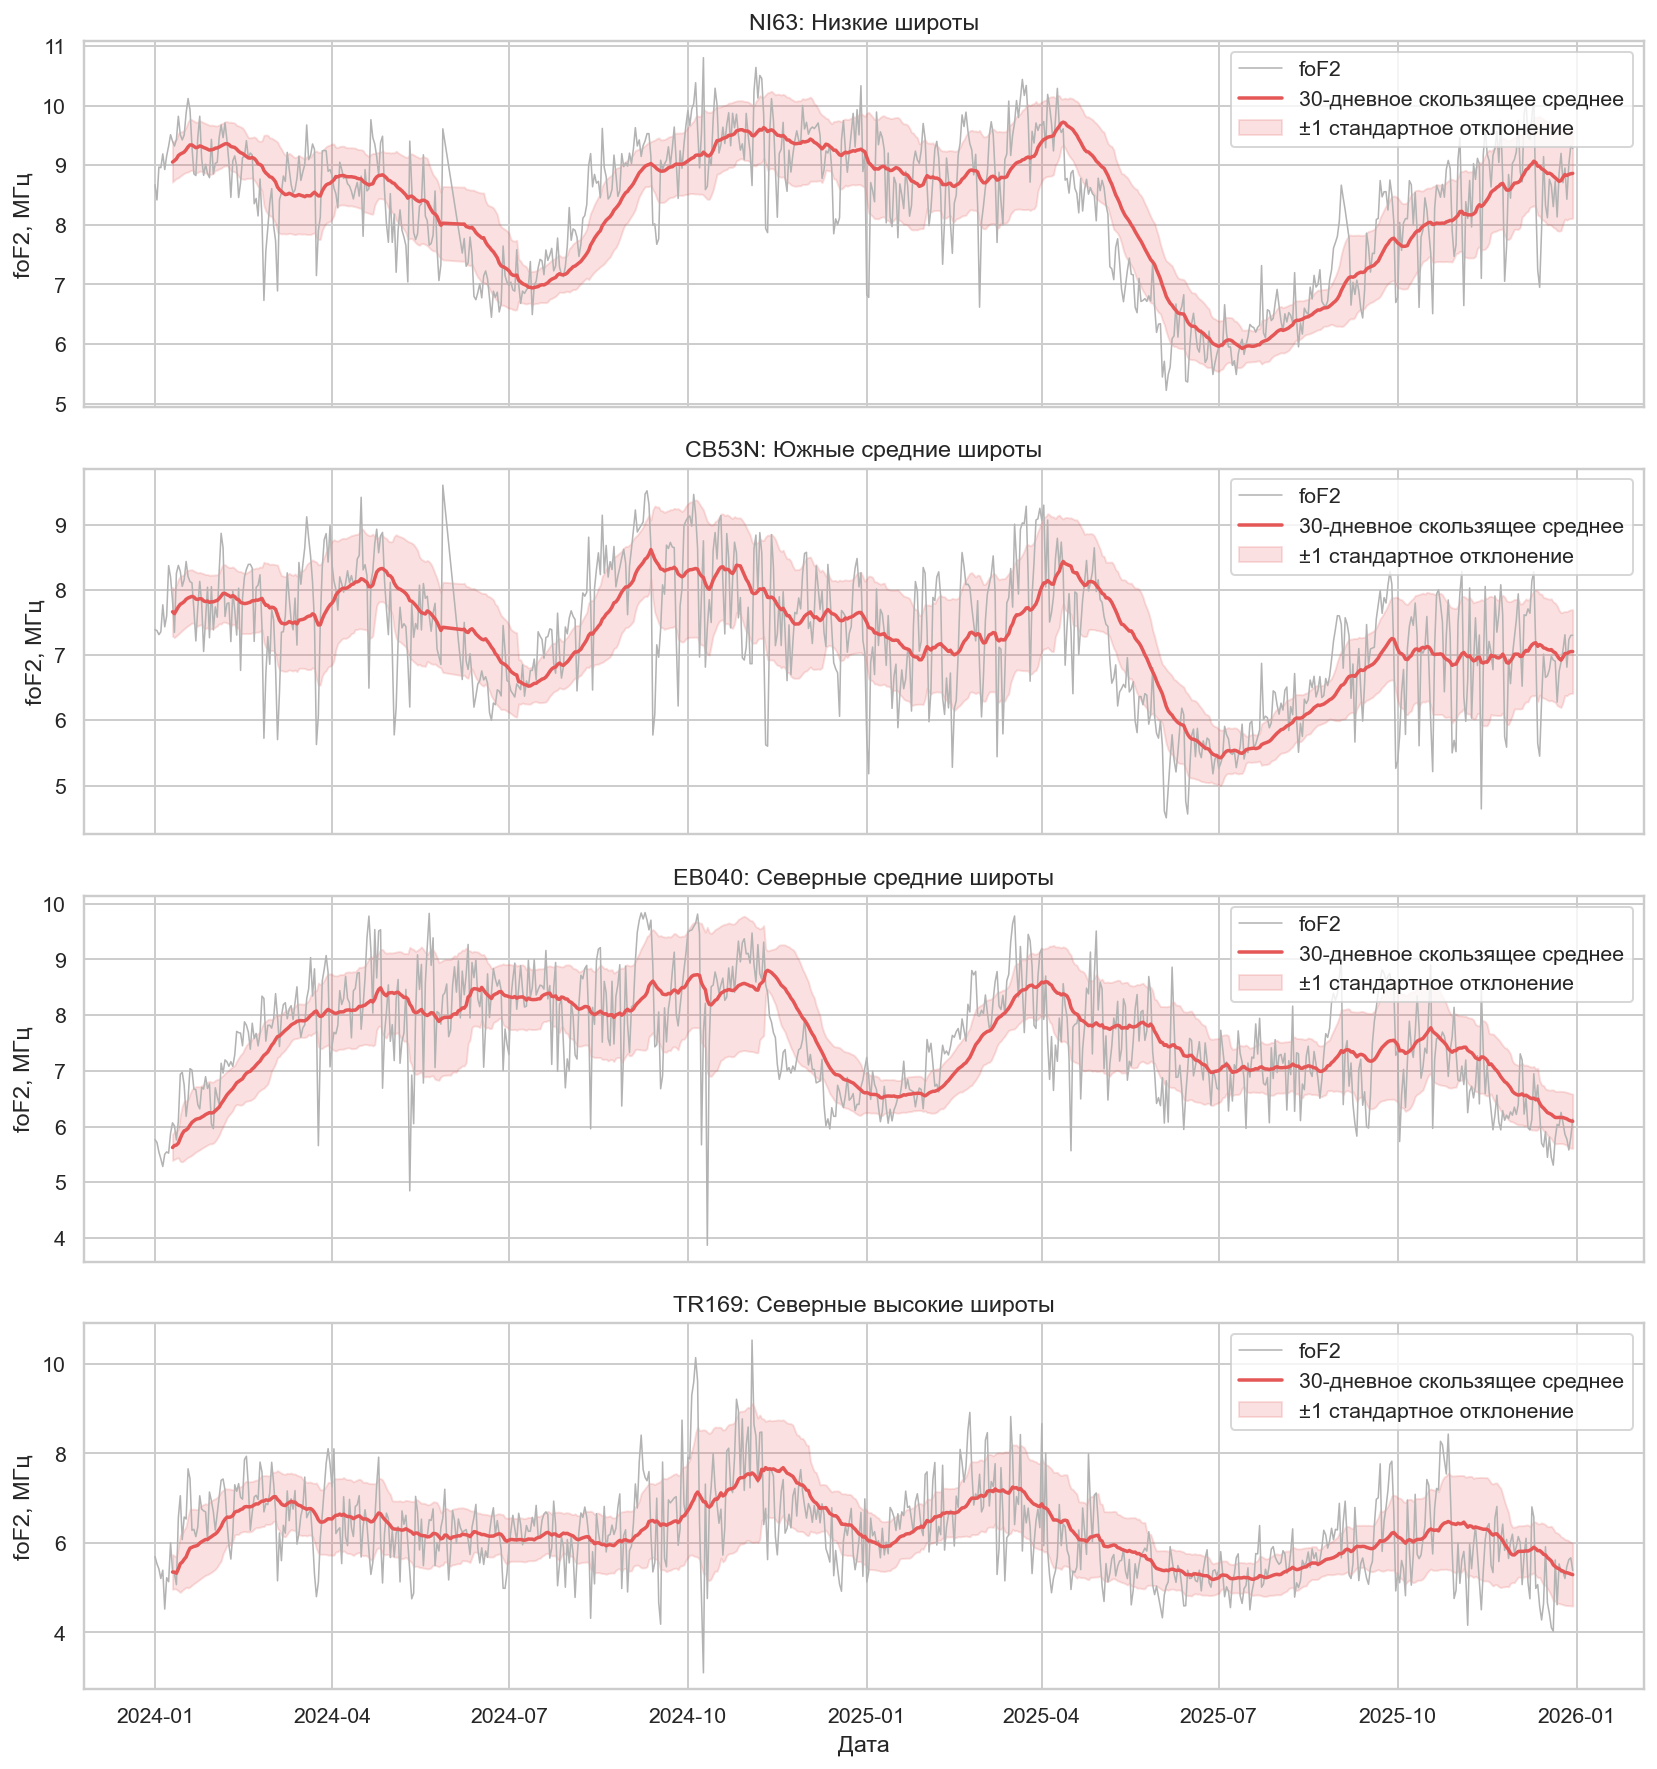

WindowsPath('D:/Проекты/IonoAutoML/reports/stationarity_latitude_analysis/training_rolling_mean_std_examples_by_latitude_zone.png')

In [13]:
# Построение графиков со скользящим средним и изменением разброса.
fig, axes = plt.subplots(len(example_stations), 1, figsize=(12, 3.2 * len(example_stations)), sharex=True)
if len(example_stations) == 1:
    axes = [axes]
for ax, station in zip(axes, example_stations):
    g = daily[daily['station'] == station].sort_values('date').set_index('date')
    y = g[TARGET]
    rolling_mean = y.rolling(30, min_periods=10).mean()
    rolling_std = y.rolling(30, min_periods=10).std()
    zone = g['latitude_zone'].iloc[0]
    ax.plot(y.index, y, color='0.70', linewidth=0.8, label='foF2')
    ax.plot(rolling_mean.index, rolling_mean, color='#E45756', linewidth=1.8, label='30-дневное скользящее среднее')
    ax.fill_between(rolling_std.index, rolling_mean - rolling_std, rolling_mean + rolling_std, color='#E45756', alpha=0.18, label='±1 стандартное отклонение')
    ax.set_title(f'{station}: {ZONE_LABELS[zone]}')
    ax.set_ylabel('foF2, МГц')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('Дата')
savefig('training_rolling_mean_std_examples_by_latitude_zone.png')

## 5. Краткий вывод для статьи

In [14]:
# Формирование краткого текстового вывода по результатам расчетов.
summary_lines = []
summary_lines.append('Проверка стационарности выполнена для дневных временных ходов foF2, сформированных из feature-строк, использованных в задаче 24-часового прогноза.')
summary_lines.append('Станции были сгруппированы по широтным зонам: низкие широты, южные средние широты, северные средние широты и северные высокие широты.')
summary_lines.append('Для каждой станции рассчитаны ADF- и KPSS-критерии, после чего результаты обобщены по широтным зонам.')
for _, row in zone_stationarity_summary.iterrows():
    if pd.isna(row['stations']):
        continue
    summary_lines.append(
        f"{row['latitude_zone_label']}: станций={int(row['stations'])}, "
        f"стационарных={int(row['stationary'])}, "
        f"тренд-стационарных={int(row['trend_stationary'])}, "
        f"нестационарных={int(row['nonstationary'])}, "
        f"доля стационарных и тренд-стационарных={row['stationary_or_trend_share'] * 100:.1f}%."
    )
text = chr(10).join(summary_lines)
(OUT_DIR / 'stationarity_training_article_summary.txt').write_text(text, encoding='utf-8')
print(text)

Проверка стационарности выполнена для дневных временных ходов foF2, сформированных из feature-строк, использованных в задаче 24-часового прогноза.
Станции были сгруппированы по широтным зонам: низкие широты, южные средние широты, северные средние широты и северные высокие широты.
Для каждой станции рассчитаны ADF- и KPSS-критерии, после чего результаты обобщены по широтным зонам.
Низкие широты: станций=11, стационарных=1, тренд-стационарных=0, нестационарных=9, доля стационарных и тренд-стационарных=9.1%.
Южные средние широты: станций=4, стационарных=0, тренд-стационарных=1, нестационарных=3, доля стационарных и тренд-стационарных=25.0%.
Северные средние широты: станций=18, стационарных=1, тренд-стационарных=3, нестационарных=14, доля стационарных и тренд-стационарных=22.2%.
Северные высокие широты: станций=2, стационарных=0, тренд-стационарных=1, нестационарных=1, доля стационарных и тренд-стационарных=50.0%.
